# 03 Data Augmentation


In [9]:
# Buckets 1, 2, 3, 4, 6, 7, 9, 10, 11, 12, 13, 14, 15
# Buckets 16, 17 for testing (inject anomalies here)

In [10]:
import string
!pip install jupyter ipykernel numpy==1.26.4 pandas seaborn matplotlib

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import os
import glob
import sys
from pathlib import Path

root_path = Path(os.getcwd()).parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path / "src"))

from utils import TAG_INFO
from faults import f1_fault, f2_fault, f3_fault, f4_fault, f5_fault
from plots import plot_fault_comparison

In [12]:
path = "../data/processed/data_11-03_10-04/clean"
all_files = glob.glob(os.path.join(path, "*.csv"))

# Order the csv's
all_files.sort(key=lambda x: int(os.path.basename(x).split('_')[2]))

# Get the last two
last_two_files = all_files[-2:]

dict_sessions = {}

for file in last_two_files:
    s_id                = int(os.path.basename(file).split('_')[2])
    dict_sessions[s_id] = pd.read_csv(file, index_col='timestamp', parse_dates=True)

print(f"{len(dict_sessions)} sessions loaded")

2 sessions loaded


| Sensor | Description | Warning Signal | Trip Signal |
|--------|-------------|---------------|-------------|
| TT-901 | Temperature — Gas Oil Separator | 135°C | 140°C |
| TT-902 | Temperature — Discharge 1 | 105°C | 110°C |
| TT-903 | Temperature — Discharge 2 | 105°C | 110°C |
| TT-904 | Oil Temperature | 90°C | 110°C |
| PT-903 | Pressure — Oil Separator | 0.4 mbar | 0.5 mbar |

Fault Catalogue


| #  | Fault Name | Root Cause (manual) | Primary Sensors Affected | Pattern |
|----|-----------|--------------------|--------------------------|---------|
| F1 | **Clogged Exhaust Filters** | Exhaust filters (EF) partially clogged | TT-902 ↑, TT-903 ↑, PT-903 ↑ | Slow gradual drift |
| F2 | **Insufficient Cooling** | Insufficient cooling / ambient temp high | TT-901 ↑, TT-902 ↑, TT-903 ↑, TT-904 ↑ | Global correlated rise |
| F3 | **Float Valve Fault** | Float valve does not work properly | PT-903 oscillating, TT-901 irregular | Oscillation / instability |
| F4 | **Stuck Vanes** | Stuck vanes (noisy operation) | PT-903 ↓, TT-902 ↑, VSD current ↑ | Pressure drop + current spike |
| F5 | **Defective Bearing** | Defective bearing | TT-904 ↑ (rapid, localised) | Fast isolated spike |
| F6 | **Clogged Inlet Filter** | Inlet filter/screen partially clogged | PT-901 ↓, PT-902 ↓ | Suction pressure gradual drop |
| F7 | **Emulsified Oil** | Machine sucked in liquids/vapour | TT-904 ↑ (slow), PT-903 irregular | Slow drift + noise |

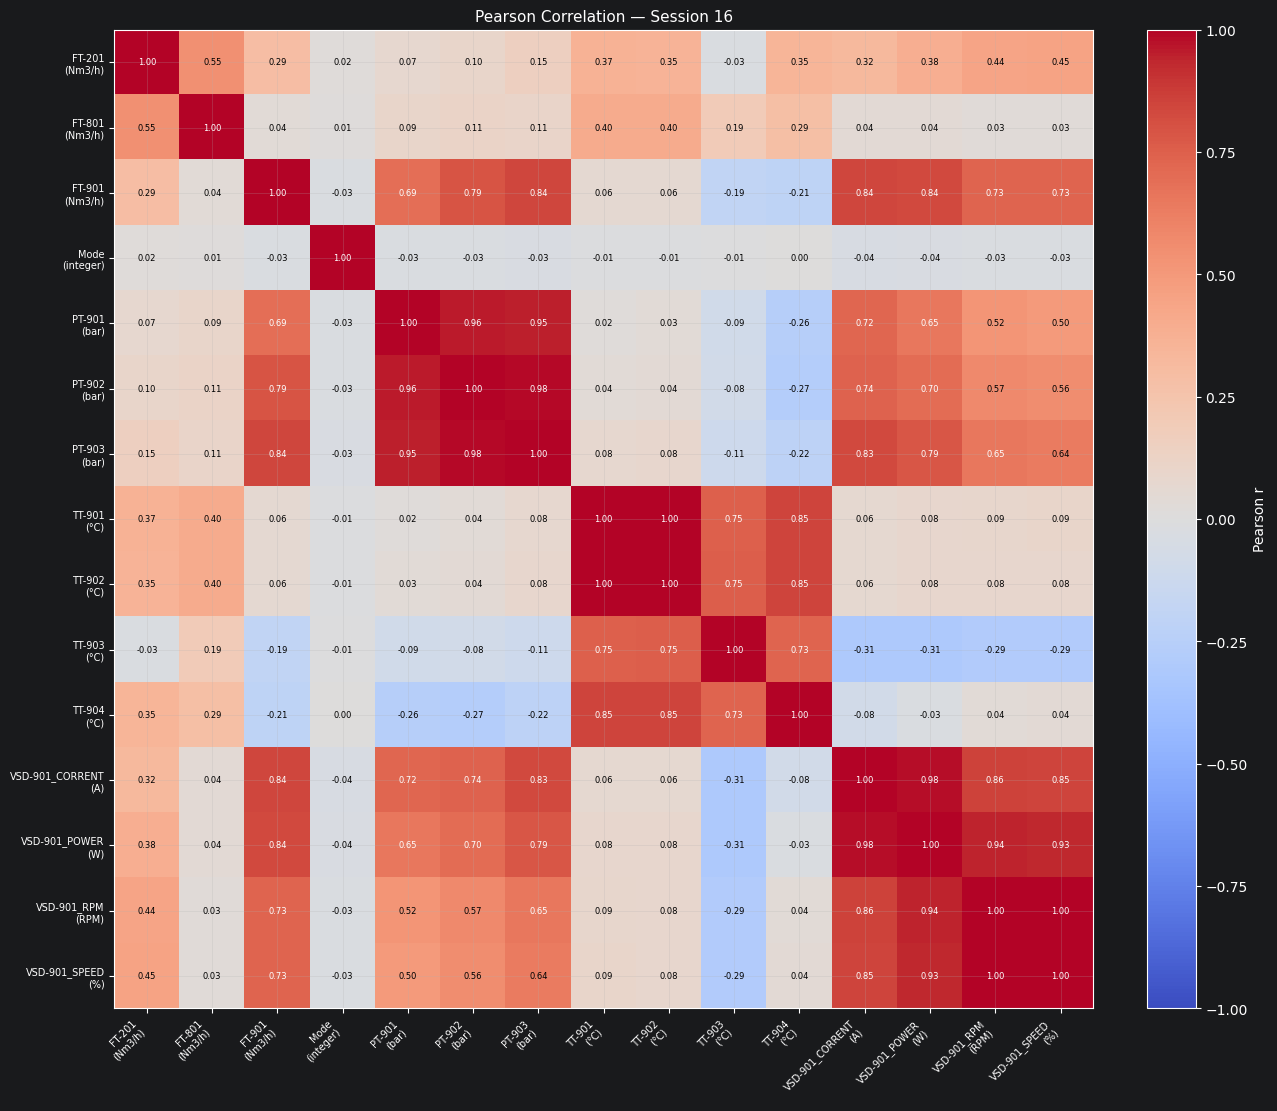

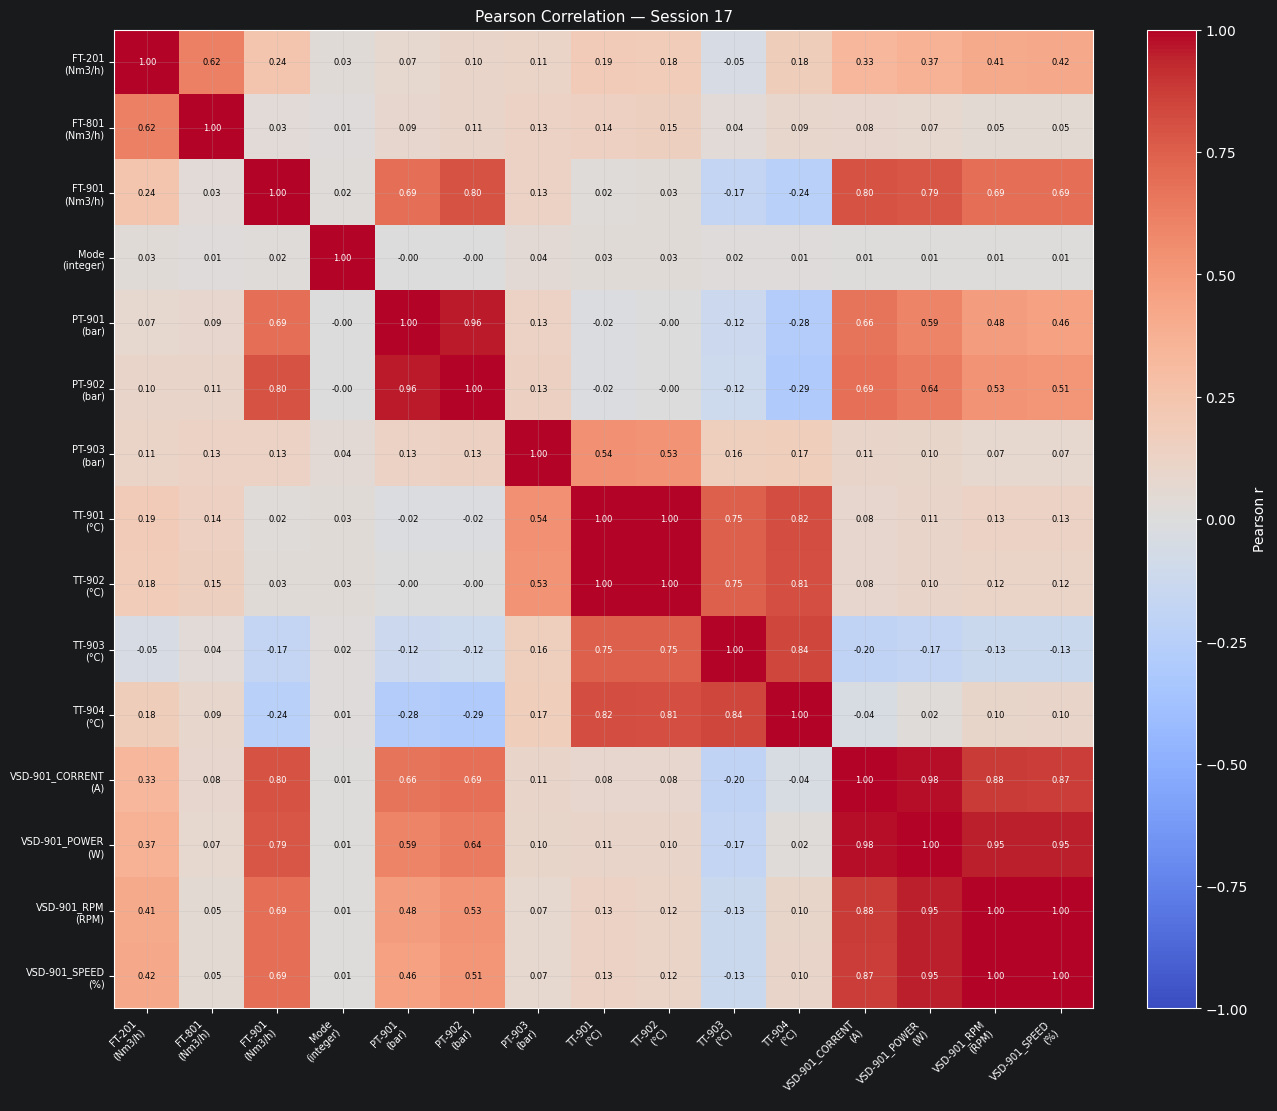

In [13]:
# Colunas a excluir da correlação
EXCLUDE_COLS = ["bucket_id", "LS-901", "time_diff"]

def plot_corr_heatmap(session_id: int, ax: plt.Axes):
    df = dict_sessions[session_id].drop(columns=[c for c in EXCLUDE_COLS if c in dict_sessions[session_id].columns])
    corr = df.corr(method="pearson", numeric_only=True)
    labels = [f"{col}\n({TAG_INFO.get(col, {}).get('unit', '?')})" for col in corr.columns]

    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="equal")

    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)

    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            value = corr.iloc[i, j]
            text_color = "white" if abs(value) > 0.65 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                    color=text_color, fontsize=6)

    ax.set_title(f"Pearson Correlation — Session {session_id}", fontsize=11)
    return im


for sid in [16, 17]:
    fig, ax = plt.subplots(figsize=(13, 11), constrained_layout=True)
    im = plot_corr_heatmap(sid, ax)
    fig.colorbar(im, ax=ax, label="Pearson r")
    plt.show()

In [14]:
output_dir = "../data/processed/data_11-03_10-04/faulty"
os.makedirs(output_dir, exist_ok=True)

# --- F1: Clogged Exhaust Filters ---
df_f1 = f1_fault(dict_sessions[16], length_time=12, start_from=0.30)
t1_s = df_f1.index.min().strftime('%Y-%m-%d_%H-%M')
t1_e = df_f1.index.max().strftime('%Y-%m-%d_%H-%M')
df_f1.to_csv(f"{output_dir}/data_session_16_F1_12-0.3_{t1_s}_to_{t1_e}.csv")

# --- F2: Insufficient Cooling ---
df_f2 = f2_fault(dict_sessions[16], length_time=12, start_from=0.30)
t2_s = df_f2.index.min().strftime('%Y-%m-%d_%H-%M')
t2_e = df_f2.index.max().strftime('%Y-%m-%d_%H-%M')
df_f2.to_csv(f"{output_dir}/data_session_16_F2_12-0.3_{t2_s}_to_{t2_e}.csv")

# --- F3: Float Valve Fault ---
df_f3 = f3_fault(dict_sessions[16], length_time=6, start_from=0.40)
t3_s = df_f3.index.min().strftime('%Y-%m-%d_%H-%M')
t3_e = df_f3.index.max().strftime('%Y-%m-%d_%H-%M')
df_f3.to_csv(f"{output_dir}/data_session_16_F3_6-0.4_{t3_s}_to_{t3_e}.csv")

# --- F4: Clogged Inlet Filter ---
# df_f4 = f4_fault(dict_sessions[16], length_time=12, start_from=0.30)
# t4_s = df_f4.index.min().strftime('%Y-%m-%d_%H-%M')
# t4_e = df_f4.index.max().strftime('%Y-%m-%d_%H-%M')
# df_f4.to_csv(f"{output_dir}/data_session_16_F4_12-0.3_{t4_s}_to_{t4_e}.csv")

# --- F5: Defective Bearing ---
df_f5 = f5_fault(dict_sessions[16], length_time=0.15, start_from=0.50)
t5_s = df_f5.index.min().strftime('%Y-%m-%d_%H-%M')
t5_e = df_f5.index.max().strftime('%Y-%m-%d_%H-%M')
df_f5.to_csv(f"{output_dir}/data_session_16_F5_0.15-0.5_{t5_s}_to_{t5_e}.csv")

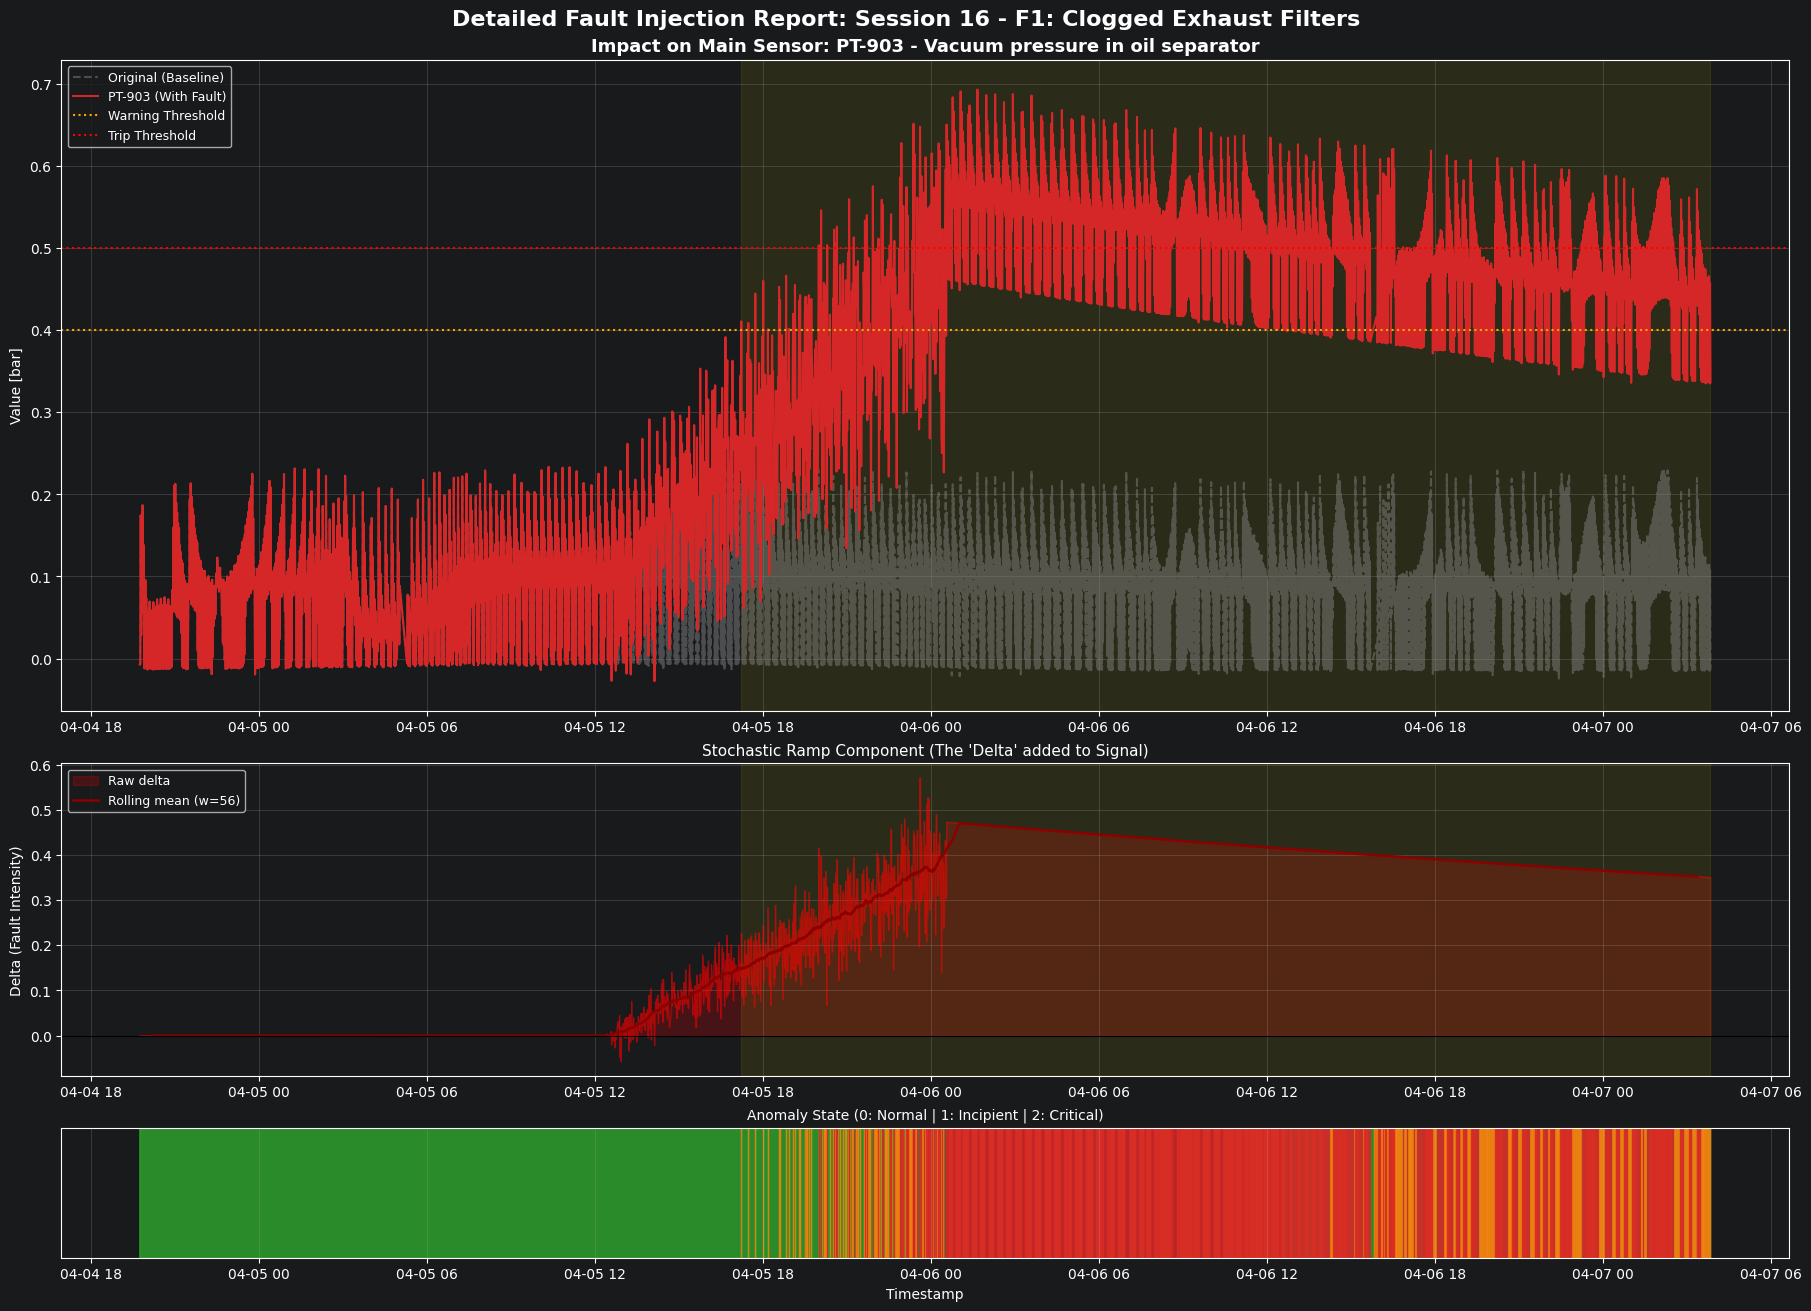

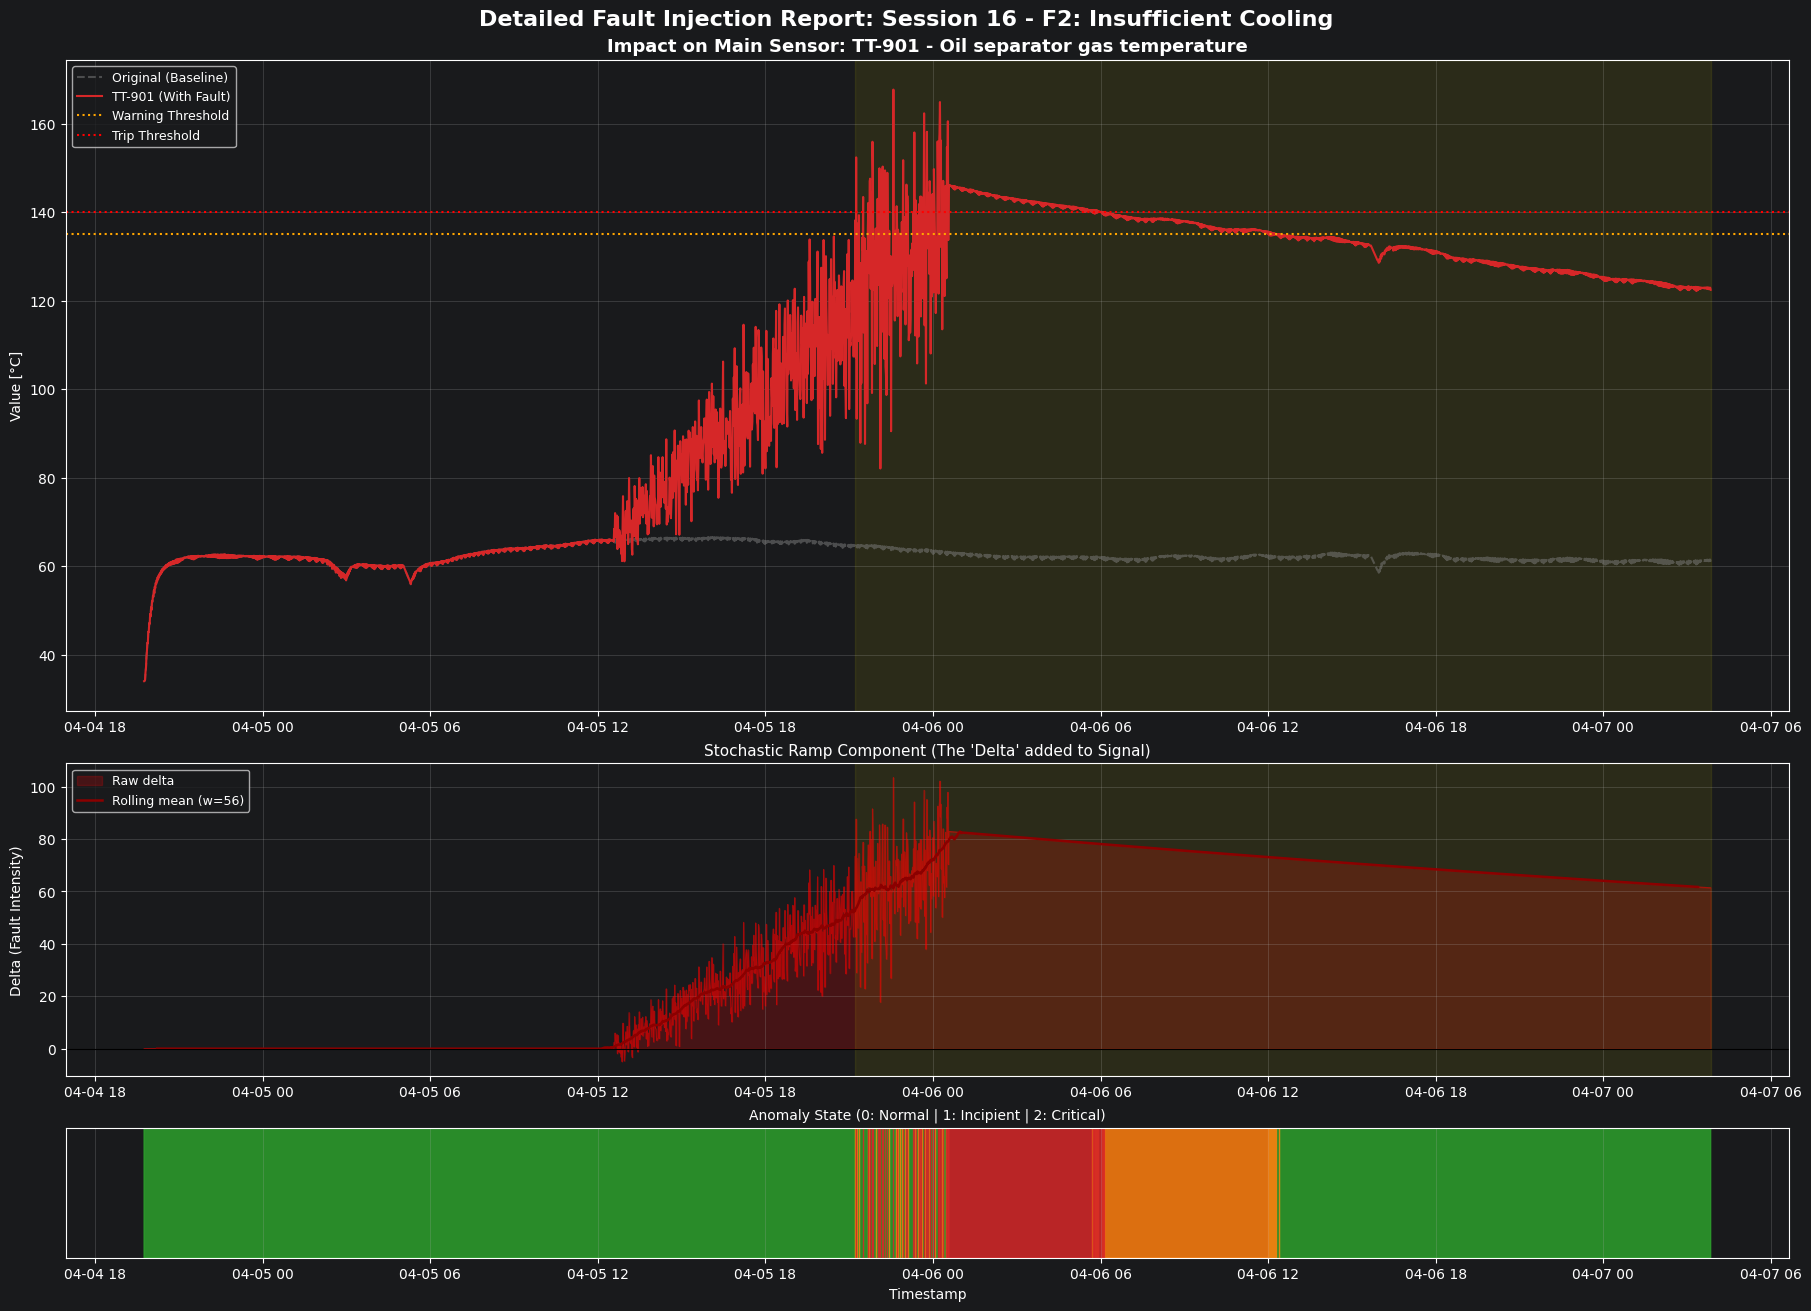

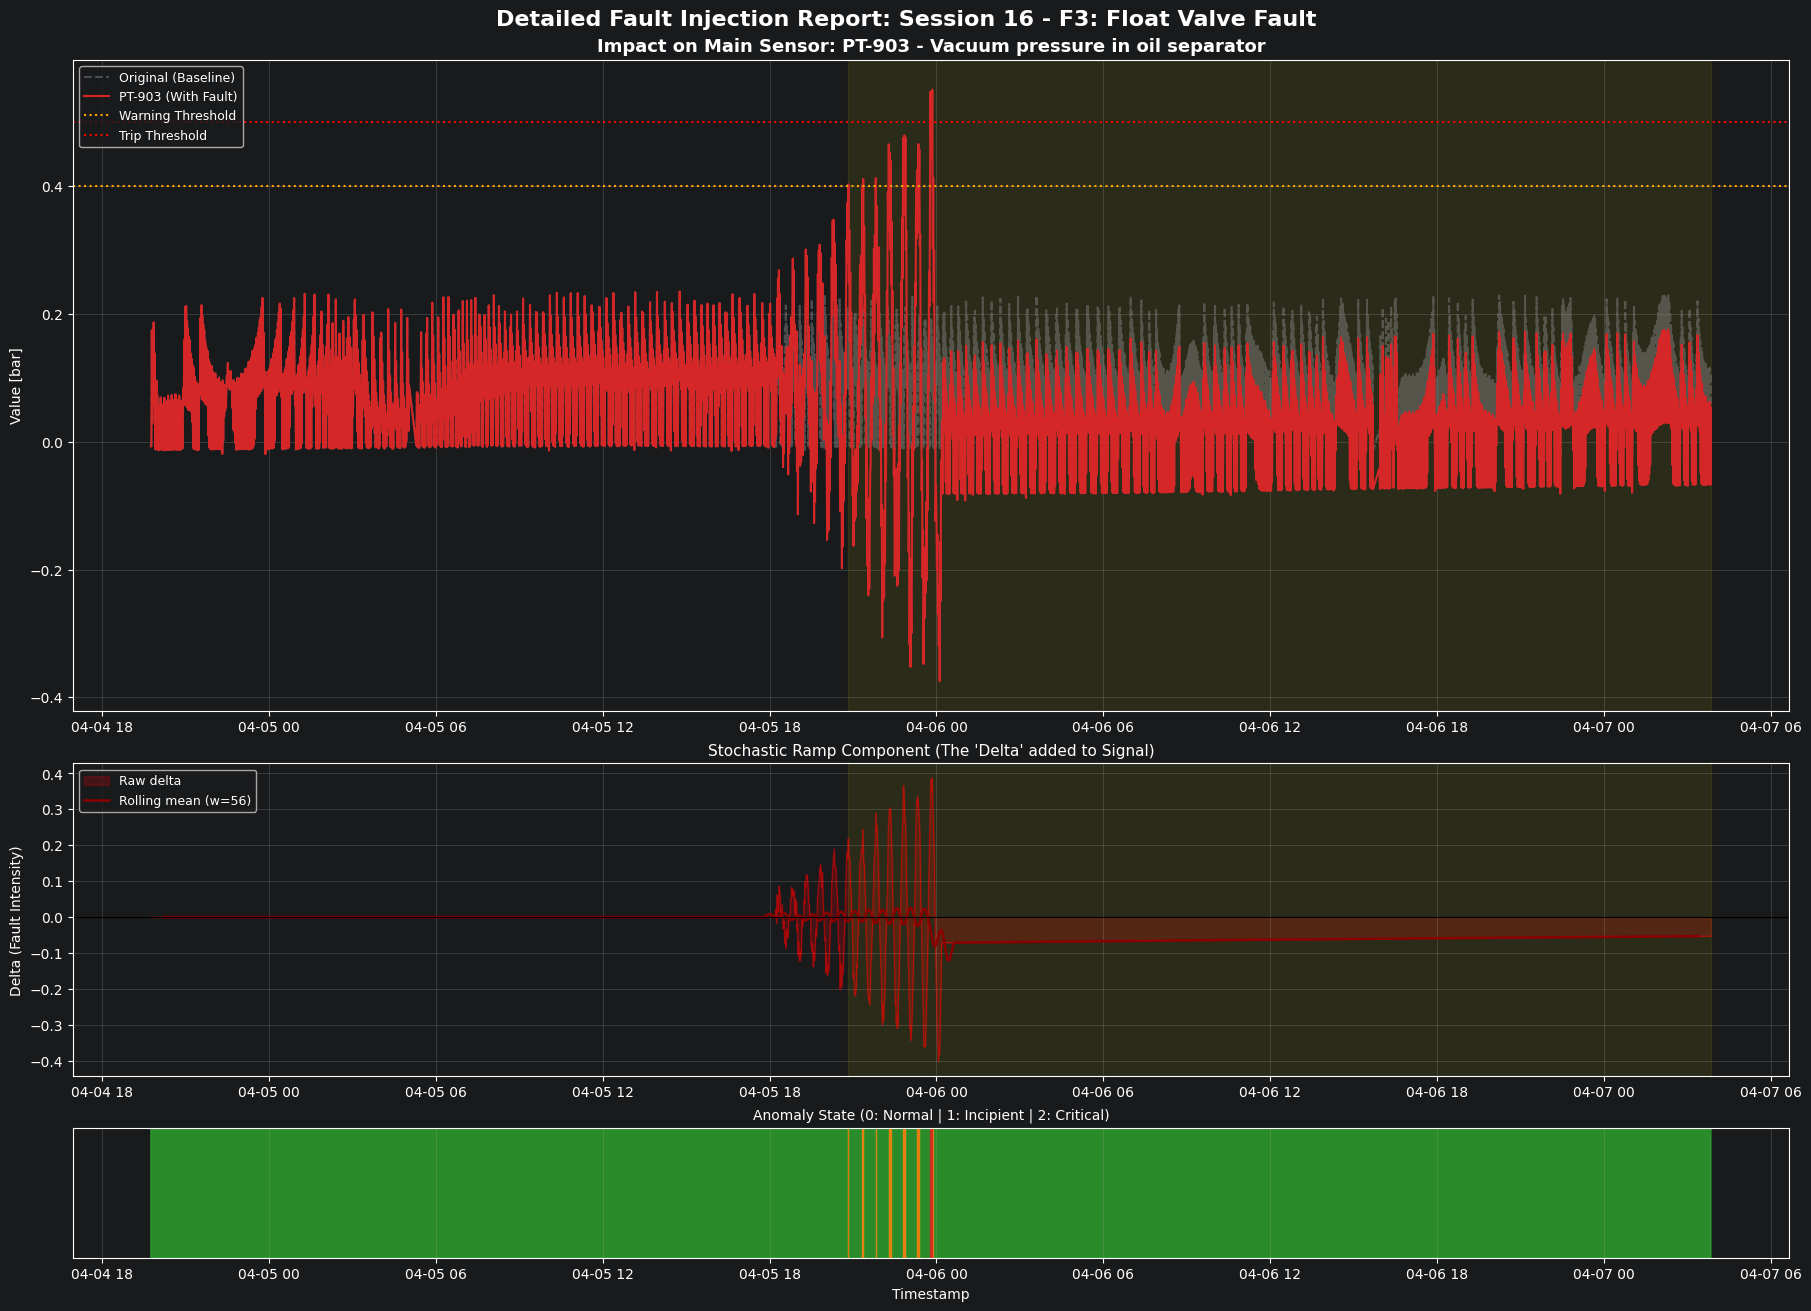

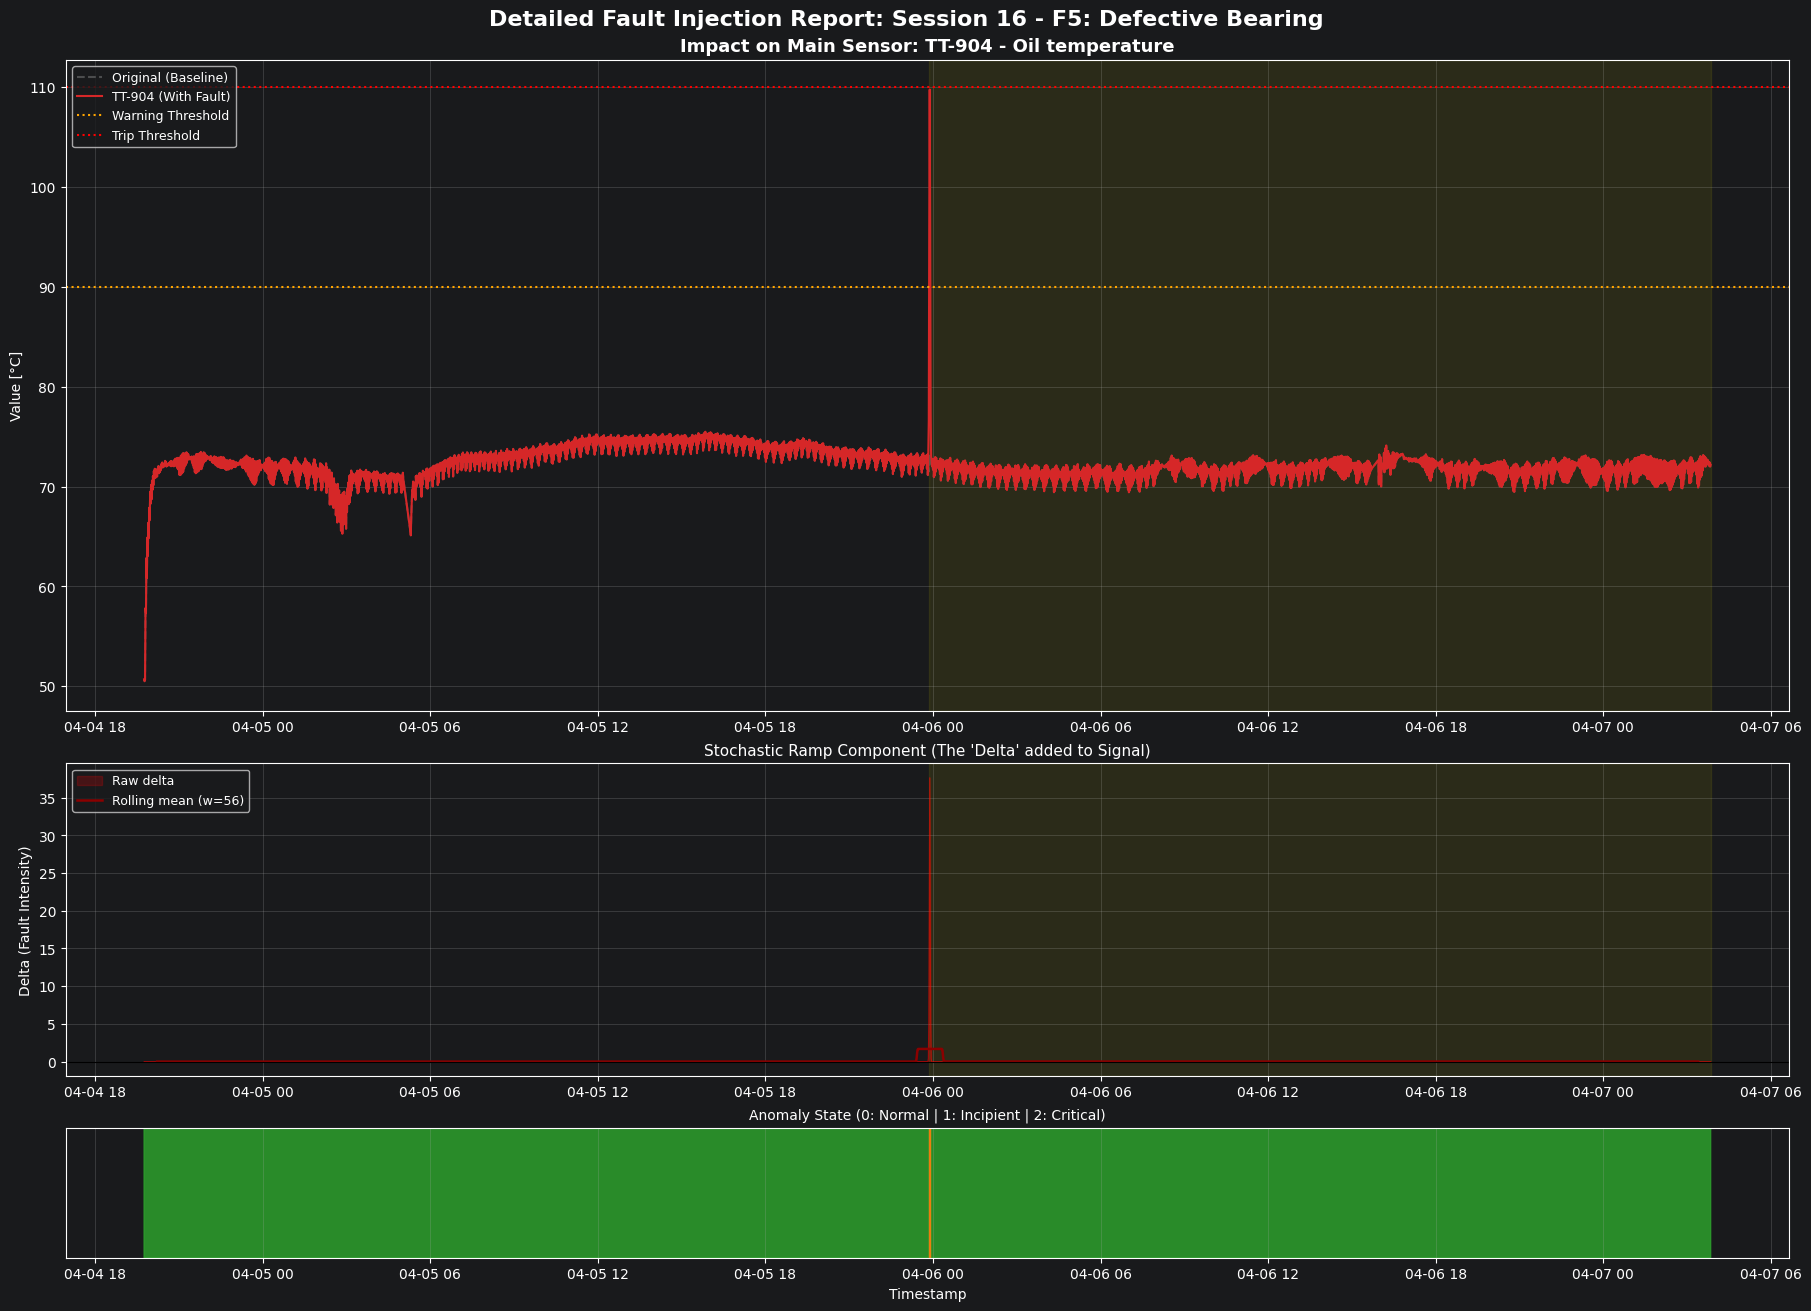

In [15]:
# --- Plots ---
plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f1,
    anchor_sensor="PT-903",
    title="Session 16 - F1: Clogged Exhaust Filters"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f2,
    anchor_sensor="TT-901",
    title="Session 16 - F2: Insufficient Cooling"
)

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f3,
    anchor_sensor="PT-903",
    title="Session 16 - F3: Float Valve Fault"
)

# plot_fault_comparison(
#     df_orig=dict_sessions[16], df_fault=df_f4,
#     anchor_sensor="PT-901",
#     title="Session 16 - F4: Clogged Inlet Filter"
# )

plot_fault_comparison(
    df_orig=dict_sessions[16], df_fault=df_f5,
    anchor_sensor="TT-904",
    title="Session 16 - F5: Defective Bearing"
)